# Анализ продуктовых метрик — интернет-магазин косметики

**Датасет:** E-Commerce Events History in Cosmetics Shop (Rees46, Kaggle)  
**Период:** октябрь 2019 — февраль 2020  
**Объем:** ~20 млн событий пользователей  
**Стек:** Python, pandas, PostgreSQL, SQLAlchemy, seaborn, matplotlib, statsmodels

**Цель:** рассчитать ключевые продуктовые метрики — воронку продаж, DAU/MAU, Retention, LTV, Churn, и проверить статистическую гипотезу об отличии конверсии в будни и выходные.

## Блок 1. Подключение к базе данных и загрузка данных

Подключаемся к локальной PostgreSQL базе `ecommerce` и загружаем 5 CSV файлов (по одному на каждый месяц) как отдельные таблицы.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine
from scipy import stats
import numpy as np

engine = create_engine('postgresql://max_power@localhost:5432/ecommerce')
print('Connected!')

Connected!


In [2]:
path = '/Users/max_power/Projects/ecommerce_events/'

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(csv_files)

['2020-Jan.csv', '2019-Dec.csv', '2020-Feb.csv', '2019-Nov.csv', '2019-Oct.csv']


In [3]:
for file in csv_files:
    table_name = file.replace('.csv', '').replace('-','_')
    df = pd.read_csv(path + file)
    df.to_sql(table_name, engine, if_exists='replace', index=False)
    print(f'Загружено: {table_name} - {df.shape[0]} строк')

Загружено: 2020_Jan - 4264752 строк
Загружено: 2019_Dec - 3533286 строк
Загружено: 2020_Feb - 4156682 строк
Загружено: 2019_Nov - 4635837 строк
Загружено: 2019_Oct - 4102283 строк


## Блок 2. Воронка продаж

Анализируем переход пользователей по этапам: просмотр → корзина → покупка.  
Используем ноябрь 2019 как наиболее репрезентативный месяц (наибольший объем событий).

In [4]:
df_nov = pd.read_sql('SELECT * FROM nov_2019', engine)

In [5]:
funnel = df_nov \
    .groupby('event_type') \
    .agg(unique_users=('user_id', 'nunique')) \
    .sort_values('unique_users', ascending=False)
print(funnel)

                  unique_users
event_type                    
view                    355643
cart                     95939
remove_from_cart         54628
purchase                 31524


In [6]:
view = funnel.loc['view', 'unique_users']
cart = funnel.loc['cart', 'unique_users']
purchase = funnel.loc['purchase', 'unique_users']

In [7]:
print(f'view - cart: {round(cart * 100/ view, 2)}%')
print(f'cart - purchase: {round(purchase * 100/ cart, 2)}%')
print(f'view - purchase: {round(purchase * 100/ view, 2)}%')

view - cart: 26.98%
cart - purchase: 32.86%
view - purchase: 8.86%


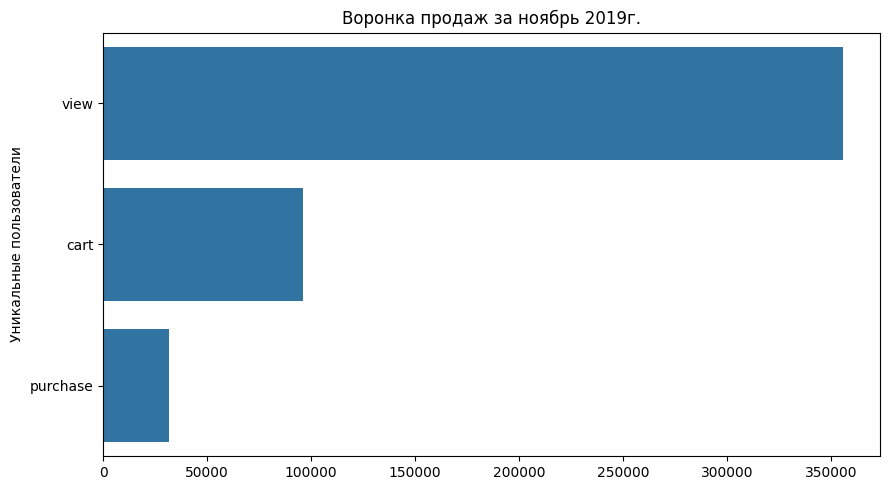

In [8]:
funnel_clean = funnel.drop('remove_from_cart')
plt.figure(figsize=(9, 5))
sns.barplot(data=funnel_clean, x='unique_users', y='event_type')
plt.title('Воронка продаж за ноябрь 2019г.')
plt.xlabel('')
plt.ylabel('Уникальные пользователи')
plt.tight_layout()
plt.show()

**Вывод:** итоговая конверсия из просмотра в покупку составляет **8.86%**.  
Узкое место — переход view→cart (26.98%): большинство пользователей уходят не добавив товар в корзину.  
Переход cart→purchase (32.86%) — более высокий, значит те кто добавил в корзину имеют серьезное намерение купить.

## Блок 3. DAU — дневная активность пользователей

Считаем количество уникальных пользователей по каждому дню ноября 2019.

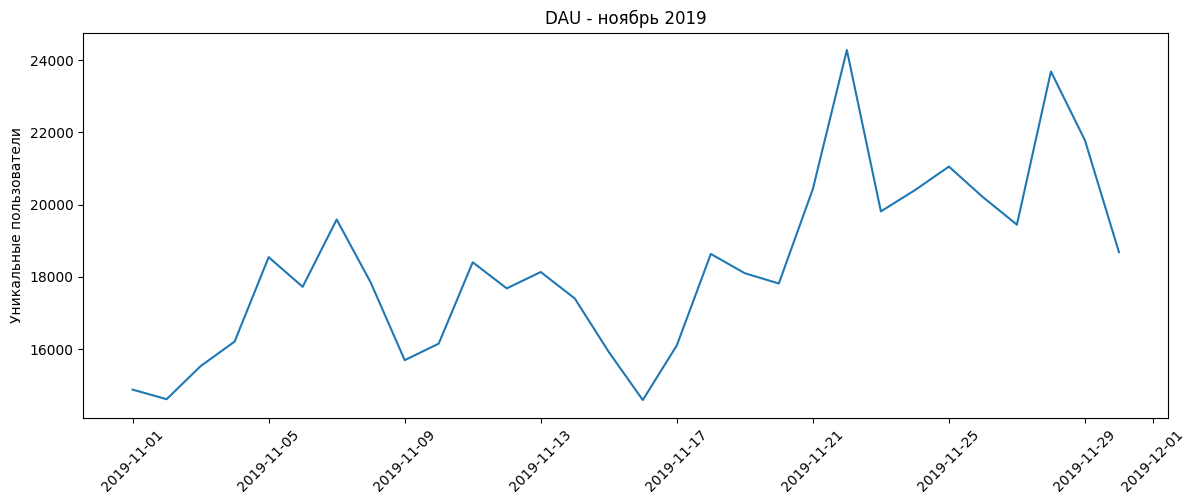

In [9]:
query = '''
SELECT 
	date(event_time) AS day_of_weak,
	count(DISTINCT user_id) AS unique_users
FROM nov_2019
GROUP BY date(event_time);
'''
df_dau = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_dau, x='day_of_weak', y='unique_users')
plt.title('DAU - ноябрь 2019')
plt.xlabel('')
plt.ylabel('Уникальные пользователи')
plt.xticks(rotation=45)
plt.show()

**Вывод:** в ноябре видны два пика — 22 ноября (пятница перед Black Friday, 24276 пользователей) и 28 ноября (сам Black Friday, 23683).  
В начале месяца активность заметно ниже (~14-15к), к концу месяца растет.

## Блок 4. MAU — месячная активность пользователей

Считаем уникальных пользователей по каждому из 5 месяцев.

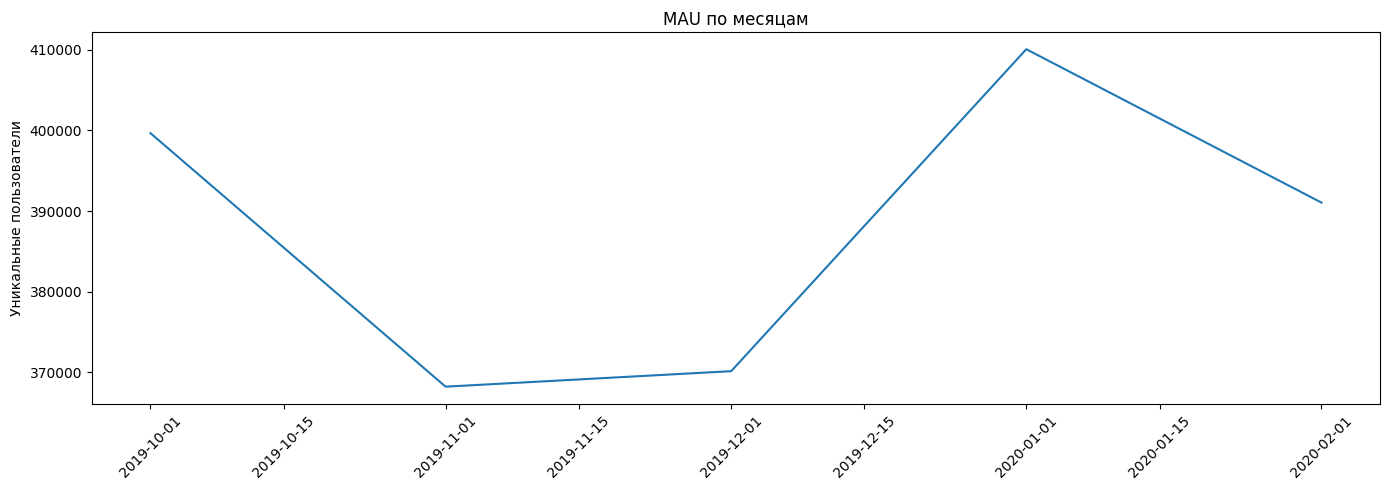

In [11]:
query = '''
SELECT 
	date_trunc('month', event_time::timestamp) AS month,
	count(DISTINCT user_id) AS unique_users
FROM (
	SELECT event_time, user_id FROM oct_2019
	UNION ALL
	SELECT event_time, user_id FROM nov_2019
	UNION ALL
	SELECT event_time, user_id FROM dec_2019
	UNION ALL
	SELECT event_time, user_id FROM jan_2020
	UNION ALL
	SELECT event_time, user_id FROM feb_2020
	) all_events
GROUP BY date_trunc('month', event_time::timestamp);
'''
df_mau = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_mau, x='month', y='unique_users')
plt.title('MAU по месяцам')
plt.xlabel('')
plt.ylabel('Уникальные пользователи')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод:** MAU стабилен в диапазоне 370-410к пользователей — роста аудитории нет.  
Интересный факт: ноябрь имеет наименьший MAU (368к), но наибольшую выручку из-за Black Friday.  
Это значит что выручку определяла не численность аудитории а покупательская активность.

## Блок 5. Когортный анализ — Retention Rate

Разбиваем пользователей на когорты по месяцу первой активности и смотрим как меняется их доля с течением времени.

In [12]:
query = '''
WITH cohorts AS (
	SELECT 
	user_id,
	min(date_trunc('month', event_time::timestamp)) AS cohort_month
FROM all_events
GROUP BY user_id
),
activity AS (
	SELECT 
		c.user_id,
		c.cohort_month,
		date_trunc('month', ae.event_time::timestamp) AS activity_month
	FROM cohorts c
	JOIN all_events ae ON ae.user_id = c.user_id
)
SELECT
    cohort_month,
    activity_month,
    COUNT(DISTINCT user_id) AS users
FROM activity
GROUP BY cohort_month, activity_month
ORDER BY cohort_month, activity_month;
'''

df_cohorts = pd.read_sql(query, engine)

In [13]:
df_cohorts['month_number'] = (df_cohorts['activity_month'].dt.year - df_cohorts['cohort_month'].dt.year) \
* 12 + (df_cohorts['activity_month'].dt.month - df_cohorts['cohort_month'].dt.month)


In [15]:
cohort_pivot = df_cohorts.pivot_table(
    index='cohort_month',
    columns='month_number',
    values='users'
)

In [16]:
cohort_retention = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3) * 100

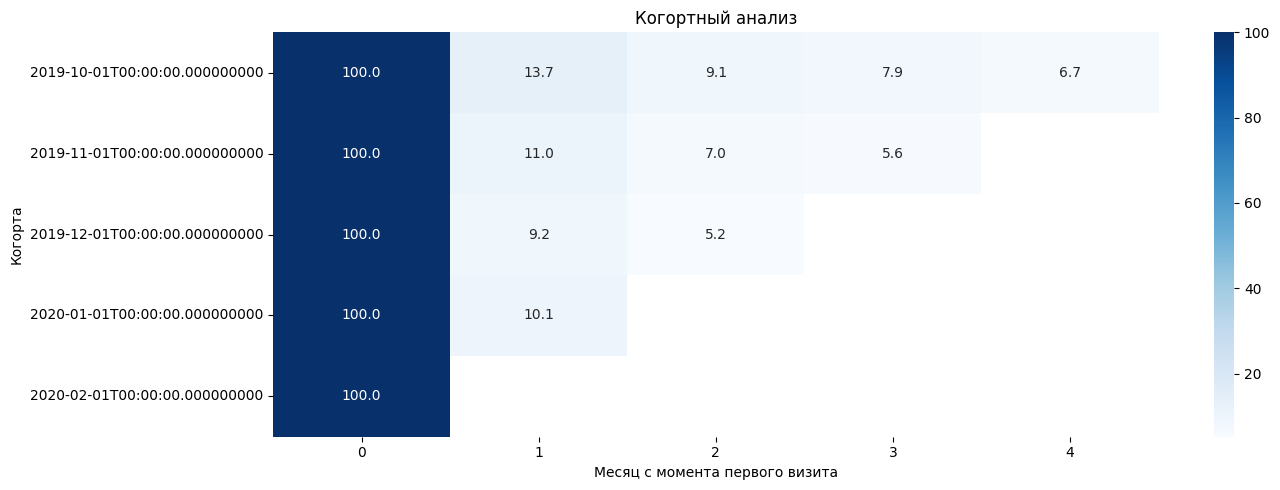

In [18]:
plt.figure(figsize=(14, 5))
sns.heatmap(cohort_retention, annot=True, fmt='.1f', cmap='Blues')
plt.title('Когортный анализ')
plt.xlabel('Месяц с момента первого визита')
plt.ylabel('Когорта')
plt.tight_layout()
plt.show()

**Вывод:** после первого месяца остается лишь **9-14%** пользователей — огромный отвал.  
Октябрьская когорта держится лучше всех — через 4 месяца еще 6.7% активны.  
Это критическая проблема — бизнес хорошо привлекает пользователей но не удерживает их.

## Блок 6. LTV — пожизненная ценность пользователя

Считаем сколько в среднем тратит один пользователь за весь период наблюдения.

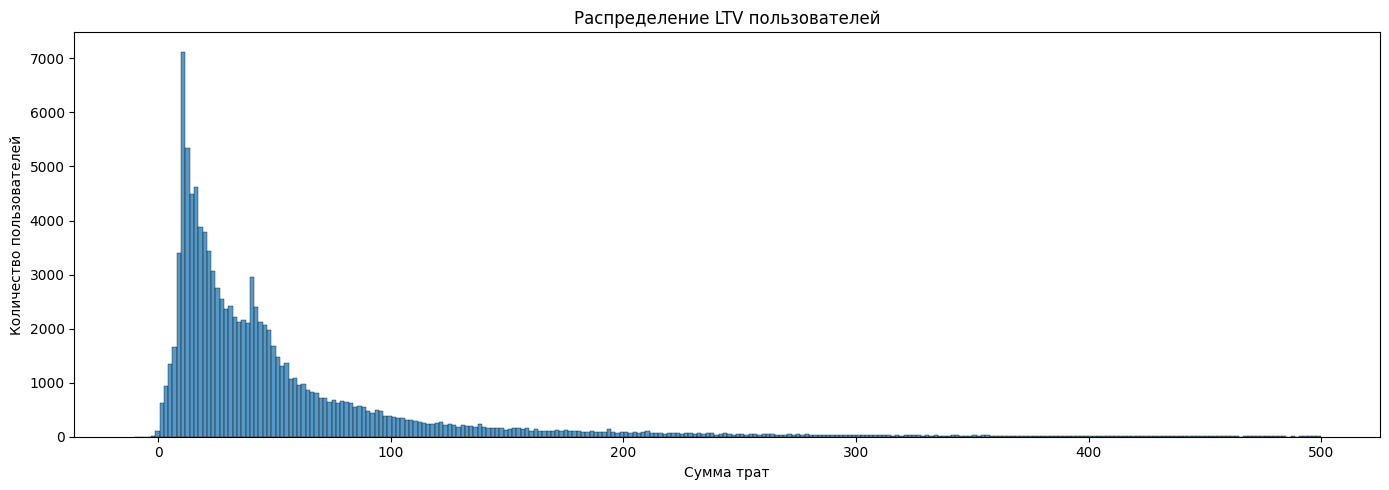

In [19]:
query = '''
SELECT 
	user_id,
	sum(price) AS total_spent
FROM all_events
WHERE event_type = 'purchase'
GROUP BY user_id;
'''

df_ltv = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.histplot(data=df_ltv[df_ltv['total_spent'] < 500], x='total_spent')
plt.title('Распределение LTV пользователей')
plt.xlabel('Сумма трат')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

**Вывод:** средние траты на пользователя — **57 у.е.**, медиана **33 у.е.**  
Медиана ниже среднего — это говорит о наличии "китов" (небольшой группы крупных покупателей) которые тянут среднее вверх.  
Большинство пользователей тратят до 50 у.е. за весь период.

## Блок 7. Churn Rate — отток пользователей

Churn — обратная сторона Retention. Показывает какой процент пользователей не вернулся в следующем месяце.

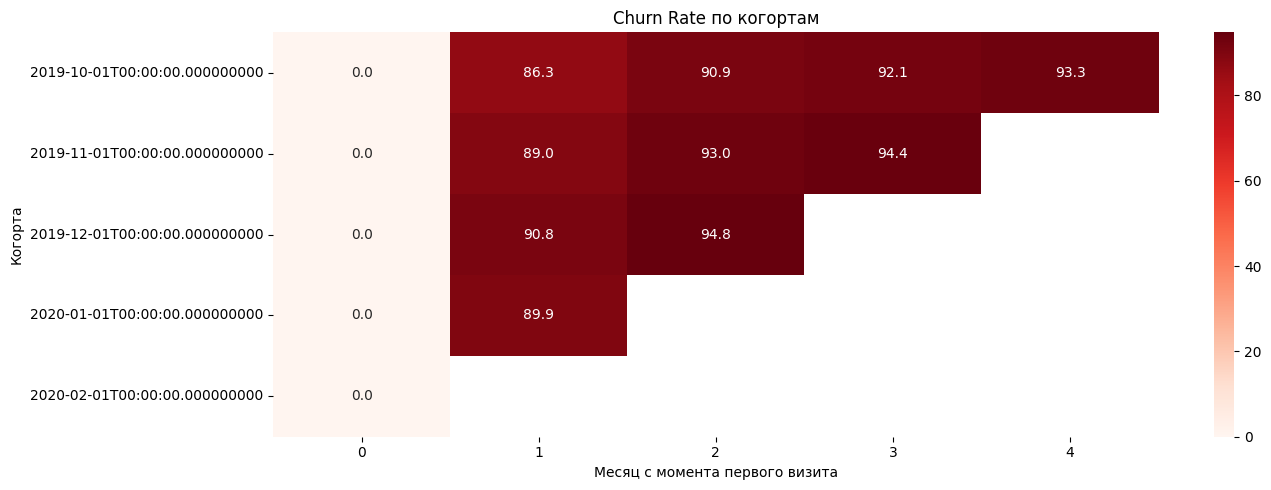

In [41]:
churn_by_cohort = 100 - cohort_retention

plt.figure(figsize=(14, 5))
sns.heatmap(churn_by_cohort, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate по когортам')
plt.xlabel('Месяц с момента первого визита')
plt.ylabel('Когорта')
plt.tight_layout()
plt.show()

In [21]:
avg_churn_month_1 = churn_by_cohort[1].mean()
print(f'Средний  Churn Rate после 1 месяца: {avg_churn_month_1}%')

Средний  Churn Rate после 1 месяца: 89.0%


**Вывод:** средний Churn Rate после первого месяца — **~88%**.  
Это подтверждает критическую проблему с удержанием — почти 9 из 10 пользователей не возвращаются.  
Для сравнения: нормой для e-commerce считается 20-30% Retention (70-80% Churn).

## Блок 8. Топ бренды и категории

Определяем какие бренды и категории товаров приносят наибольшую выручку.

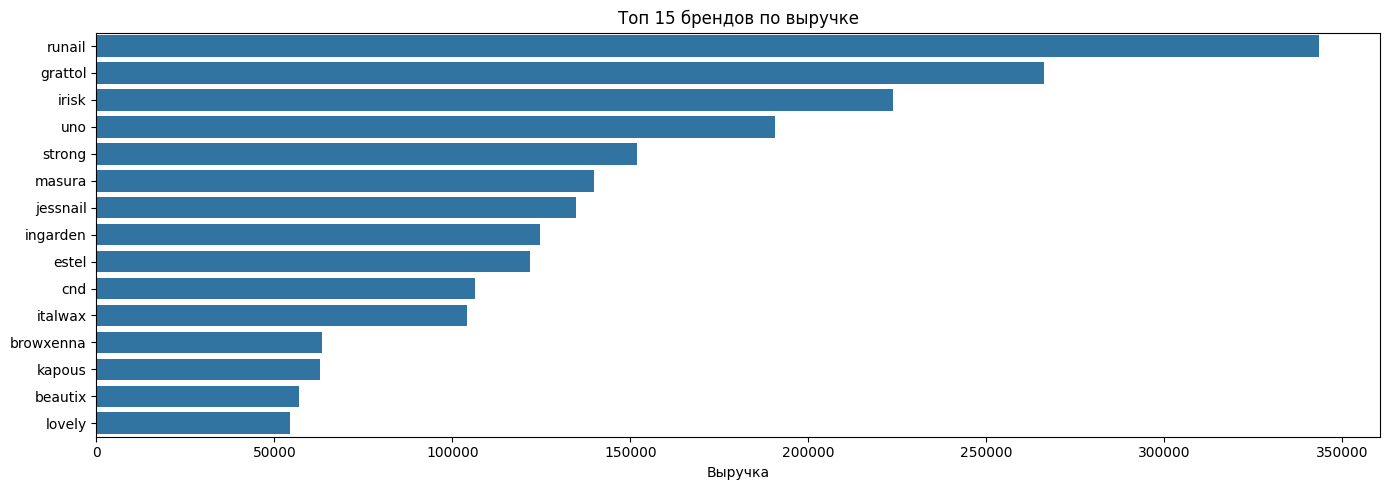

In [22]:
query = '''
SELECT
	brand,
	count(*) AS purchases,
	round(sum(price::numeric), 2) AS total_revenue
FROM all_events
WHERE event_type = 'purchase' AND brand IS NOT NULL 
GROUP BY brand
ORDER BY total_revenue DESC
LIMIT 15;
'''
df_brands = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.barplot(data=df_brands, x='total_revenue', y='brand')
plt.title('Топ 15 брендов по выручке')
plt.xlabel('Выручка')
plt.ylabel('')
plt.tight_layout()
plt.show()

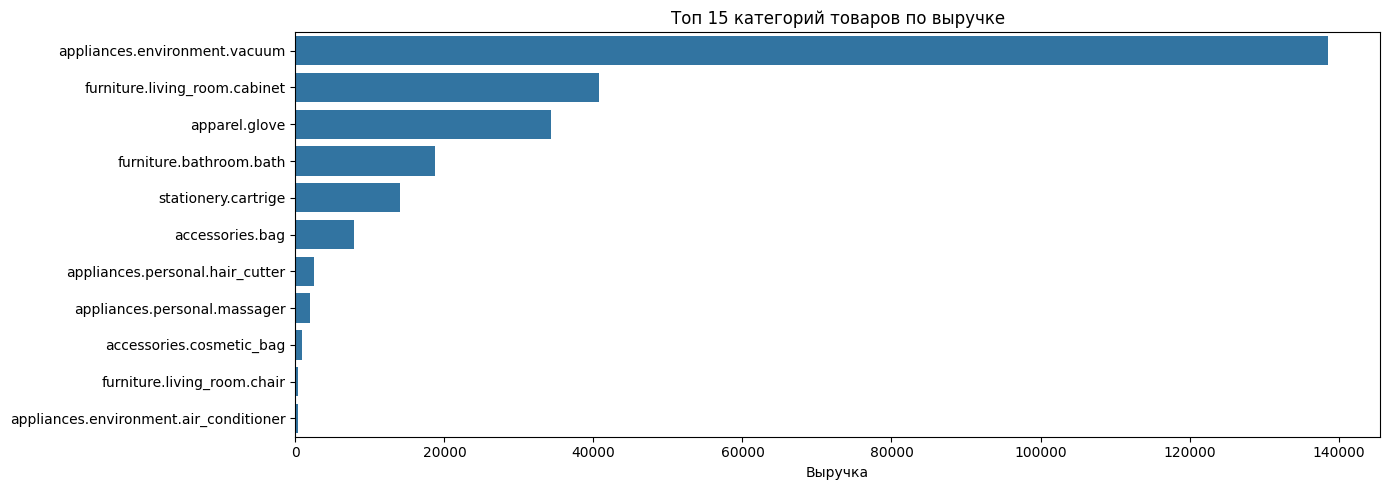

In [24]:
query = '''
SELECT
	category_code,
	count(*) AS purchases,
	round(sum(price::numeric), 2) AS total_revenue
FROM all_events
WHERE event_type = 'purchase' AND category_code IS NOT NULL 
GROUP BY category_code
ORDER BY total_revenue DESC
LIMIT 20;
'''

df_categories = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.barplot(data=df_categories, x='total_revenue', y='category_code')
plt.title('Топ 15 категорий товаров по выручке')
plt.xlabel('Выручка')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Вывод:** лидер по выручке среди брендов — **runail**, среди категорий — **appliances**.  
Это ключевые драйверы выручки — на них стоит делать акцент при планировании маркетинга и закупок.

## Блок 9. A/B тест — конверсия в будни vs выходные

**Гипотеза:** конверсия в покупку выше в выходные дни чем в будни.  
Проверяем с помощью Z-теста для пропорций (стандартный метод для сравнения конверсий).

In [28]:
query = '''
SELECT 
	CASE 
		WHEN extract(dow FROM EVENT_time::timestamp) IN (0, 6) THEN 'weekend'
		ELSE 'weekday'
	END AS day_type,
	event_type,
	count(DISTINCT user_id) AS unique_users
FROM all_events
WHERE event_type IN ('view', 'purchase')
GROUP BY day_type, event_type;
'''

df_dif_days = pd.read_sql(query, engine)

In [30]:
df_pivot = df_dif_days.pivot(index='day_type', columns='event_type', values='unique_users')

In [54]:
df_pivot['conversion'] = ((df_pivot['purchase'] / df_pivot['view']) * 100).round(3)
df_pivot

event_type,purchase,view,conversion
day_type,,,
weekday,87706,1235617,7.098
weekend,33290,555105,5.997


In [56]:
from statsmodels.stats.proportion import proportions_ztest

number_of_buyers = np.array([df_pivot.loc['weekday', 'purchase'], df_pivot.loc['weekend', 'purchase']])
number_of_beholder = np.array([df_pivot.loc['weekday', 'view'], df_pivot.loc['weekend', 'view']])



In [57]:
z_stat, p_value = proportions_ztest(number_of_buyers, number_of_beholder)

In [58]:
print(f'Конверсия будни: {df_pivot.loc["weekday", "conversion"]:.4f}')
print(f'Конверсия выходные: {df_pivot.loc["weekend", "conversion"]:.4f}')
print(f'Z-статистика: {z_stat:.4f}')
print(f'P-value: {p_value:.6f}')

if p_value < 0.05:
    print('Разница статистически значима!')
else:
    print('Разница НЕ значима — это может быть случайность')

Конверсия будни: 7.0980
Конверсия выходные: 5.9970
Z-статистика: 27.1493
P-value: 0.000000
Разница статистически значима!


**Вывод:** гипотеза **не подтвердилась** — конверсия в будни (7.1%) выше чем в выходные (6.0%).  
P-value практически равен нулю — разница статистически значима.  
Пользователи магазина косметики активнее совершают покупки в рабочее время — возможно в обеденный перерыв или между рабочими задачами.  
**Важная оговорка:** при таком объеме данных (20 млн событий) даже небольшая разница становится статистически значимой. Практическая значимость разницы в 1.1 процентного пункта — умеренная.

## Итоговые выводы и рекомендации

### Ключевые метрики:
- **Воронка:** итоговая конверсия view→purchase — 8.86%, узкое место — переход в корзину (26.98%)
- **MAU:** стабильные 370-410к пользователей, роста нет
- **Retention:** критически низкий — 9-14% после первого месяца
- **Churn:** ~88% пользователей не возвращаются
- **LTV:** медианный пользователь тратит 33 у.е. за 5 месяцев
- **Топ бренд:** runail, топ категория: appliances
- **A/B тест:** конверсия в будни (7.1%) статистически значимо выше чем в выходные (6.0%)

### Рекомендации:
- Внедрить программу лояльности для повышения Retention
- Улучшить UX на этапе добавления в корзину — это главное узкое место воронки
- Сфокусировать маркетинговые активности на рабочие дни — конверсия выше
- Сегментировать пользователей по LTV и работать с "китами" отдельно
- Запустить реактивационные email-кампании для churned пользователей